# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Liying Ma

**ID**: Lm698

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4850/HW/hw05-LM698`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Dates
using Optim

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

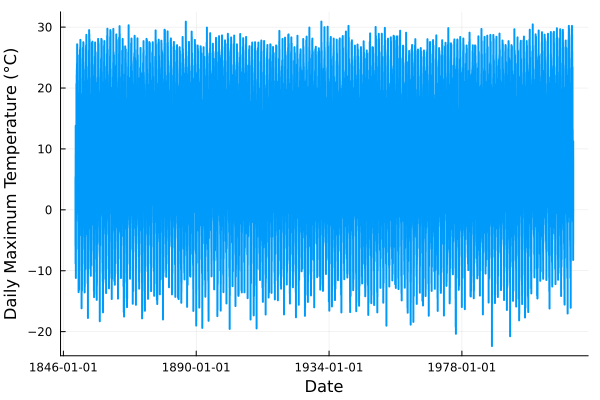

In [3]:
df = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(df.Day, df.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?

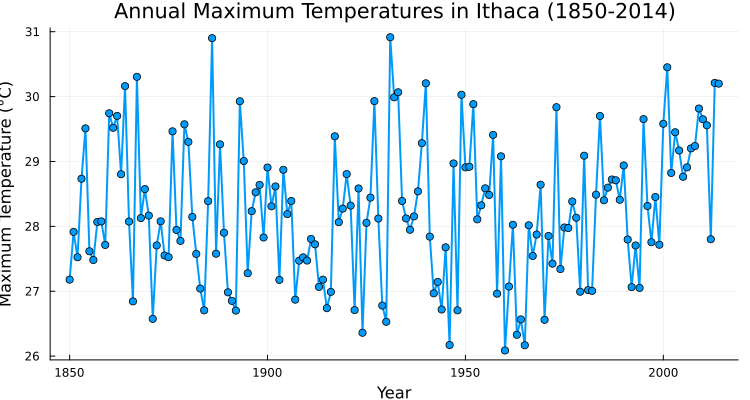

In [4]:
# Convert Day column to Date type and extract year
df[!, :Day] = Date.(df[!, :Day])
df[!, :Year] = year.(df[!, :Day])

# Group by year and find maximum temperature
annual_max = combine(groupby(df, :Year), :TempMax => maximum => :AnnualMaxTemp)

# Sort by year (just in case)
sort!(annual_max, :Year)

# Plot the annual maximum temperatures
plot(annual_max.Year, annual_max.AnnualMaxTemp, 
     marker=:circle, linewidth=2, legend=false,
     title="Annual Maximum Temperatures in Ithaca (1850-2014)",
     xlabel="Year", ylabel="Maximum Temperature (°C)",
     grid=true, size=(750, 400))

In [5]:
# Coding reference: BEE 4750 Lec 19: Modeling Extreme Values
# find GEV fit
# for most distributions we could use Distributions.fit(), but this isn't implemented in Distributions.jl for GEV
df_max = annual_max.AnnualMaxTemp
init_θ = [mean(df_max), std(df_max), 0.1]
gev_lik(θ) = -sum(logpdf(GeneralizedExtremeValue(θ[1], θ[2], θ[3]), df_max))
θ_mle = Optim.optimize(gev_lik, init_θ).minimizer

3-element Vector{Float64}:
 28.237567323626923
  1.2623260912114262
  0.125

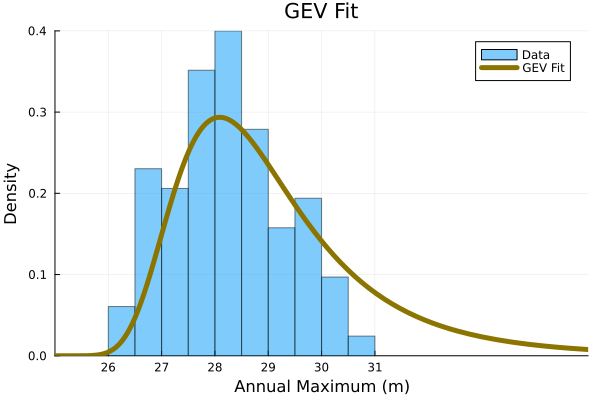

In [6]:
# Create the plot
p = plot(title="GEV Fit", xlabel="Annual Maximum (m)", ylabel="Density", legend=:topright)

# Histogram of the data
histogram!(p, df_max, bins=20, normalize=:pdf, alpha=0.5, label="Data")

# Add the fitted GEV density
plot!(GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3]), linewidth=5, label="GEV Fit", color=:gold4)
xticks!(p, 26:31)
xlims!(25, 35)

# Display the plot
display(p)

In [7]:
T = 100  # return period in years
p = 1 - 1 / T  # exceedance probability
gev_dist = GeneralizedExtremeValue(θ_mle[1], θ_mle[2], θ_mle[3])

# Quantile function gives the return level
T100 = quantile(gev_dist, p)
println("100-year return level: $(round(T100, digits=2)) °C")

100-year return level: 36.09 °C


In [8]:
function gev_negloglik_ns(θ)
    mu_0, mu_1, sigma, s = θ
    if sigma <= 0
        return Inf
    end
    try
        mu = mu_0 .+ mu_1 .* t
        ll = 0.0
        for (i, y) in enumerate(temps)
            ll += logpdf(GeneralizedExtremeValue(mu[i], sigma, s), y)
        end
        return -ll  # return negative log-likelihood
    catch
        return Inf
    end
end

# Define t = year - 1850 for scaling
t = annual_max.Year .- 1850
temps = annual_max.AnnualMaxTemp

# Initial guess
init_θ = [mean(temps), 0.01, std(temps), 0.1]

result = optimize(gev_negloglik_ns, [-100.0, -1.0, 0.01, -0.5], [100.0, 1.0, 10.0, 0.5], init_θ, Fminbox())
θ_hat = result.minimizer

# Extract results
println("Fitted parameters:")
println("mu(t) = $(round(θ_hat[1], digits=3)) + $(round(θ_hat[2], digits=5)) × year")
println("sigma = $(round(θ_hat[3], digits=3)), s = $(round(θ_hat[4], digits=3))")


Fitted parameters:
mu(t) = 27.666 + 0.00203 × year
sigma = 1.016, s = -0.221


In [9]:
# AIC Evaluation
# Stationary
stat_nll = gev_lik(θ_mle)
k = 3
AIC_stat = 2k + 2 * stat_nll
println("Stationary GEV AIC = $(round(AIC_stat, digits=2))")


Stationary GEV AIC = 554.1


In [10]:
# Non-Stationary
non_stat_nll = gev_negloglik_ns(θ_hat)
k = 4
AIC_nonstat = 2k + 2 * non_stat_nll
println("Non-stationary GEV AIC = $(round(AIC_nonstat, digits=2))")

Non-stationary GEV AIC = 493.59


**Answer**:

- Since the shape parameter is greater than zero, the type of GEV distribution would be heavy-tailed. And the 100-yr return level of the annual maximum temperature is 36.09 °C

- The differene between the AICs is 60.51, which is larger than 10. Therefore we could conclude that the stationary GEV model has weak or no support compared to the nonstationary GEV model.

### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

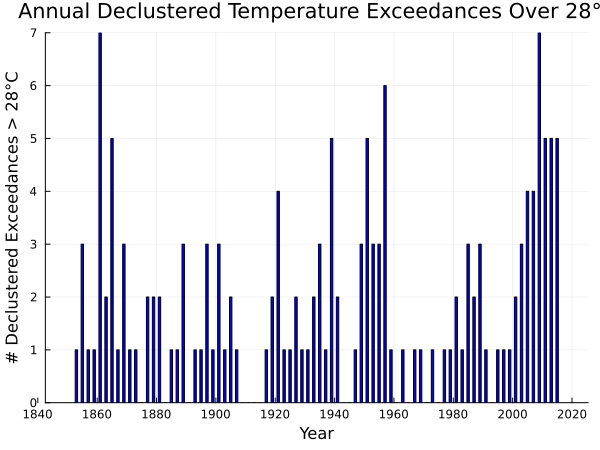

In [11]:
# Coding reference: BEE 4850 Lec 20: Peaks Over Thresholds
# cluster data points which occur within period
function assign_cluster(dates::Vector{Date}, window::Dates.Period)
    cluster_index = 1
    clusters = zeros(Int, length(dates))
    for i in 1:length(dates)
        if clusters[i] == 0
            # Assign cluster to all dates within ±window of the current date
            clusters[abs.(dates .- dates[i]) .<= window] .= cluster_index
            cluster_index += 1
        end
    end
    return clusters
end

# cluster exceedances that occur within a four-hour window
# @transform is a macro from DataFramesMeta.jl which adds a new column based on a data transformation
thresh = 28.0
df_exceed = df[df.TempMax .> thresh, :]
df_exceed[!, :cluster] = assign_cluster(df_exceed.Day, Dates.Day(3))
# find maximum value within cluster
df_decluster = combine(groupby(df_exceed, :cluster)) do group
    group[argmax(group.TempMax), :]
end

df_decluster[!, :Year] = year.(df_decluster.Day)
exceed_by_year = combine(groupby(df_decluster, :Year), nrow => :Exceedances)

histogram(
    exceed_by_year.Year;
    weights = exceed_by_year.Exceedances,
    bins = length(exceed_by_year.Year),  # one bin per year
    xlabel = "Year",
    ylabel = "# Declustered Exceedances > 28°C",
    title = "Annual Declustered Temperature Exceedances Over 28°C",
    label = false,
    xticks = 15,
    bar_width = 0.8,
    size = (600, 450),
    legend = false,
    linecolor = :black,
    fillcolor = :blue
)

**Answer:**

Based on the plot, pre-1950 period shows exceedances are present but sparse and erratic; in post-2000 period appears to be a denser, sustained cluster of years with 4–7 exceedances. Especially since 2005, there’s a notable uptick. So visually, there is a potential upward trend is present, especially in recent decades. But it's not smooth or consistent, and could be obscured by natural variability.

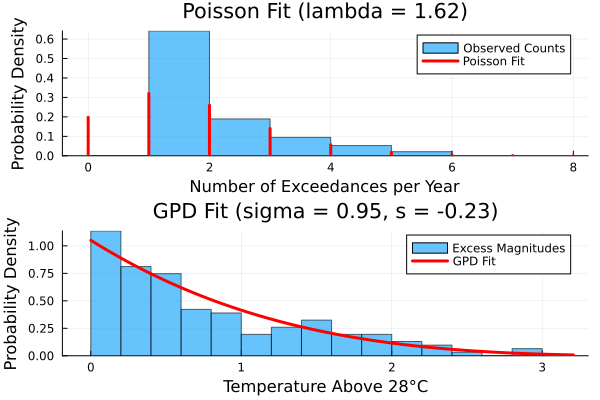

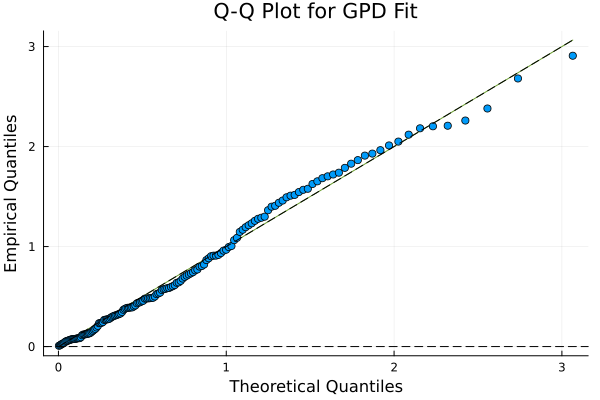

In [12]:
excess_magnitudes = df_decluster.TempMax .- thresh
annual_counts = combine(groupby(df_decluster, :Year), nrow => :Count).Count
years = df_decluster.Year

# Fit Poisson distribution to counts
count_dist = fit(Poisson, annual_counts)
lambda = mean(annual_counts)

# Fit GPD to excess magnitudes
init_θ = [1.0, 1.0]
low_bds = [0.0, -Inf]
up_bds = [Inf, Inf]
gpd_lik(θ) = -sum(logpdf(GeneralizedPareto(0.0, θ[1], θ[2]), excess_magnitudes))
θ_mle = Optim.optimize(gpd_lik, low_bds, up_bds, init_θ).minimizer
gpd_fit = GeneralizedPareto(0.0, θ_mle[1], θ_mle[2])

# Plot
p = plot(layout=(2,1), size=(600,400))

# Poisson fit
histogram!(p[1], annual_counts, bins=0:maximum(annual_counts)+1,
    label="Observed Counts", 
    xlabel="Number of Exceedances per Year",
    ylabel="Probability Density",
    normalize=:pdf,
    alpha=0.6,
    title="Poisson Fit (lambda = $(round(lambda, digits=2)))"
)
plot!(p[1], count_dist, linewidth=3, label="Poisson Fit", color=:red)

# GPD fit
x_vals = range(0, maximum(excess_magnitudes)*1.1, length=100)
histogram!(p[2], excess_magnitudes, bins=20,
    label="Excess Magnitudes",
    xlabel="Temperature Above 28°C",
    ylabel="Probability Density",
    normalize=:pdf,
    alpha=0.6,
    title="GPD Fit (sigma = $(round(θ_mle[1], digits=2)), s = $(round(θ_mle[2], digits=2)))"
)
plot!(p[2], x_vals, pdf.(gpd_fit, x_vals), 
    linewidth=3, label="GPD Fit", color=:red)

# Q-Q plot
p_qq = qqplot(gpd_fit, excess_magnitudes,
    xlabel="Theoretical Quantiles",
    ylabel="Empirical Quantiles",
    title="Q-Q Plot for GPD Fit",
    legend=false,
    size=(600,400))
hline!([0], linestyle=:dash, color=:black)
plot!(identity, linestyle=:dash, color=:black)

display(p)
display(p_qq)

Most points lie close to the 45-degree line, indicating that the GPD provides a good fit to the exceedance magnitudes. Some deviations appear at the upper tail, suggesting slight underestimation of the most extreme values, but overall the model captures the distribution well.

In [13]:
function RL100(sigma,s,m,lambda)
    return 1+((sigma/s)*((m*lambda)^(s)-1))
end

T_100 = round(RL100(0.95,-0.23,100,1.62) + 28, digits=2)

31.85

**Answer:**

- The GPD distribution looks heavy-tailed.
- The 100-yr return level of the annual maximum temperature is estimated to be 31.85 °C, which is slightly lower than the one in Question 1 (36.09 °C). The GEV model in Question 1 is based on block maxima (e.g., annual maxima), which tends to emphasize more extreme values and is more sensitive to the largest observations in the dataset. The Poisson–GPD fit models both the frequency and the magnitude of exceedances. This model can provide more stable estimates in the presence of many moderate exceedances rather than a few extreme outliers. Therefore, the lower return level from the Poisson–GPD model suggests that the GEV model may overestimate the 100-year event due to its reliance on only the most extreme data points. The Poisson–GPD model incorporates more data (all exceedances), potentially giving a more robust estimate of the return level when extreme values are sparse.